# Name-Nishanth MS

## 1. Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("SuperMarket Analysis.csv")

In [3]:
df.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


In [4]:
df.shape

(1000, 17)

In [5]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [9]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


## 2. Data Cleaning and Preparation

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.dtypes

,0
Invoice ID,object
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,float64


In [15]:
if 'TotalSales' not in df.columns:
    df['TotalSales'] = df['Sales']

In [16]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'TotalSales'],
      dtype='object')

## 3. Exploratory Data Analysis

In [17]:
top3 = (df.groupby('Product line')['Sales'].sum().sort_values(ascending=False).head(3))

In [18]:
top3

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315


In [20]:
branch=(df.groupby('Branch')['Sales'].mean().sort_values(ascending=False)).head(1)
branch

,Sales
Branch,
Giza,337.099715


In [21]:
df['Customer type'].value_counts()

,count
Customer type,
Member,565
Normal,435


In [23]:
avg_spending = (df.groupby('Customer type')['Sales'].mean().sort_values(ascending=False))
avg_spending

,Sales
Customer type,
Member,335.742945
Normal,306.372379


## 4. Visualizations

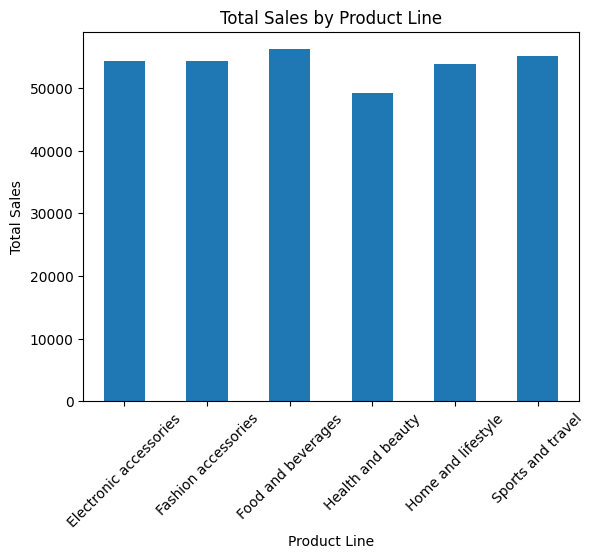

In [24]:
TotalSales = df.groupby('Product line')['Sales'].sum()

plt.figure()
TotalSales.plot(kind='bar')
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

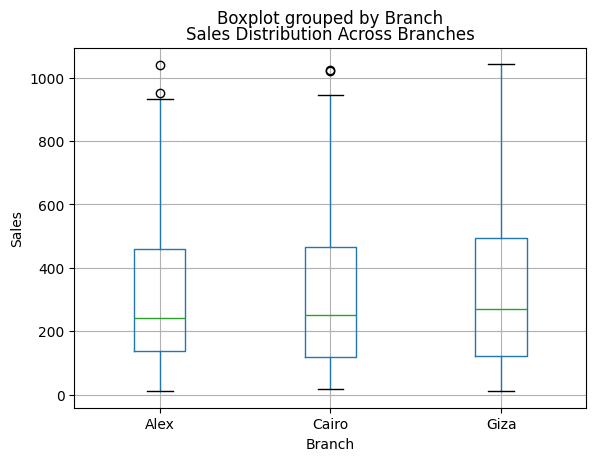

In [26]:
plt.figure()
df.boxplot(column='Sales', by='Branch')
plt.title("Sales Distribution Across Branches")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.show()

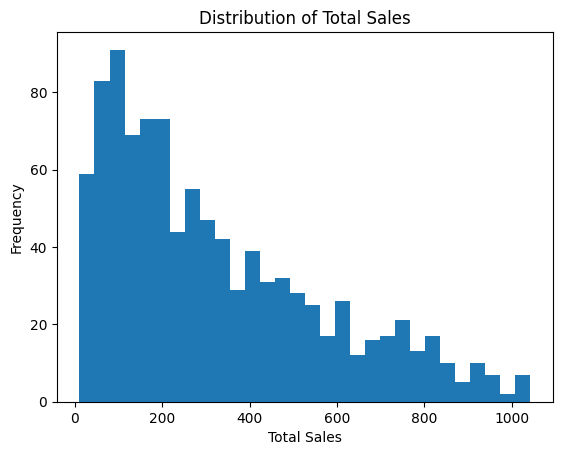

In [27]:
plt.figure()
plt.hist(df['TotalSales'], bins=30)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

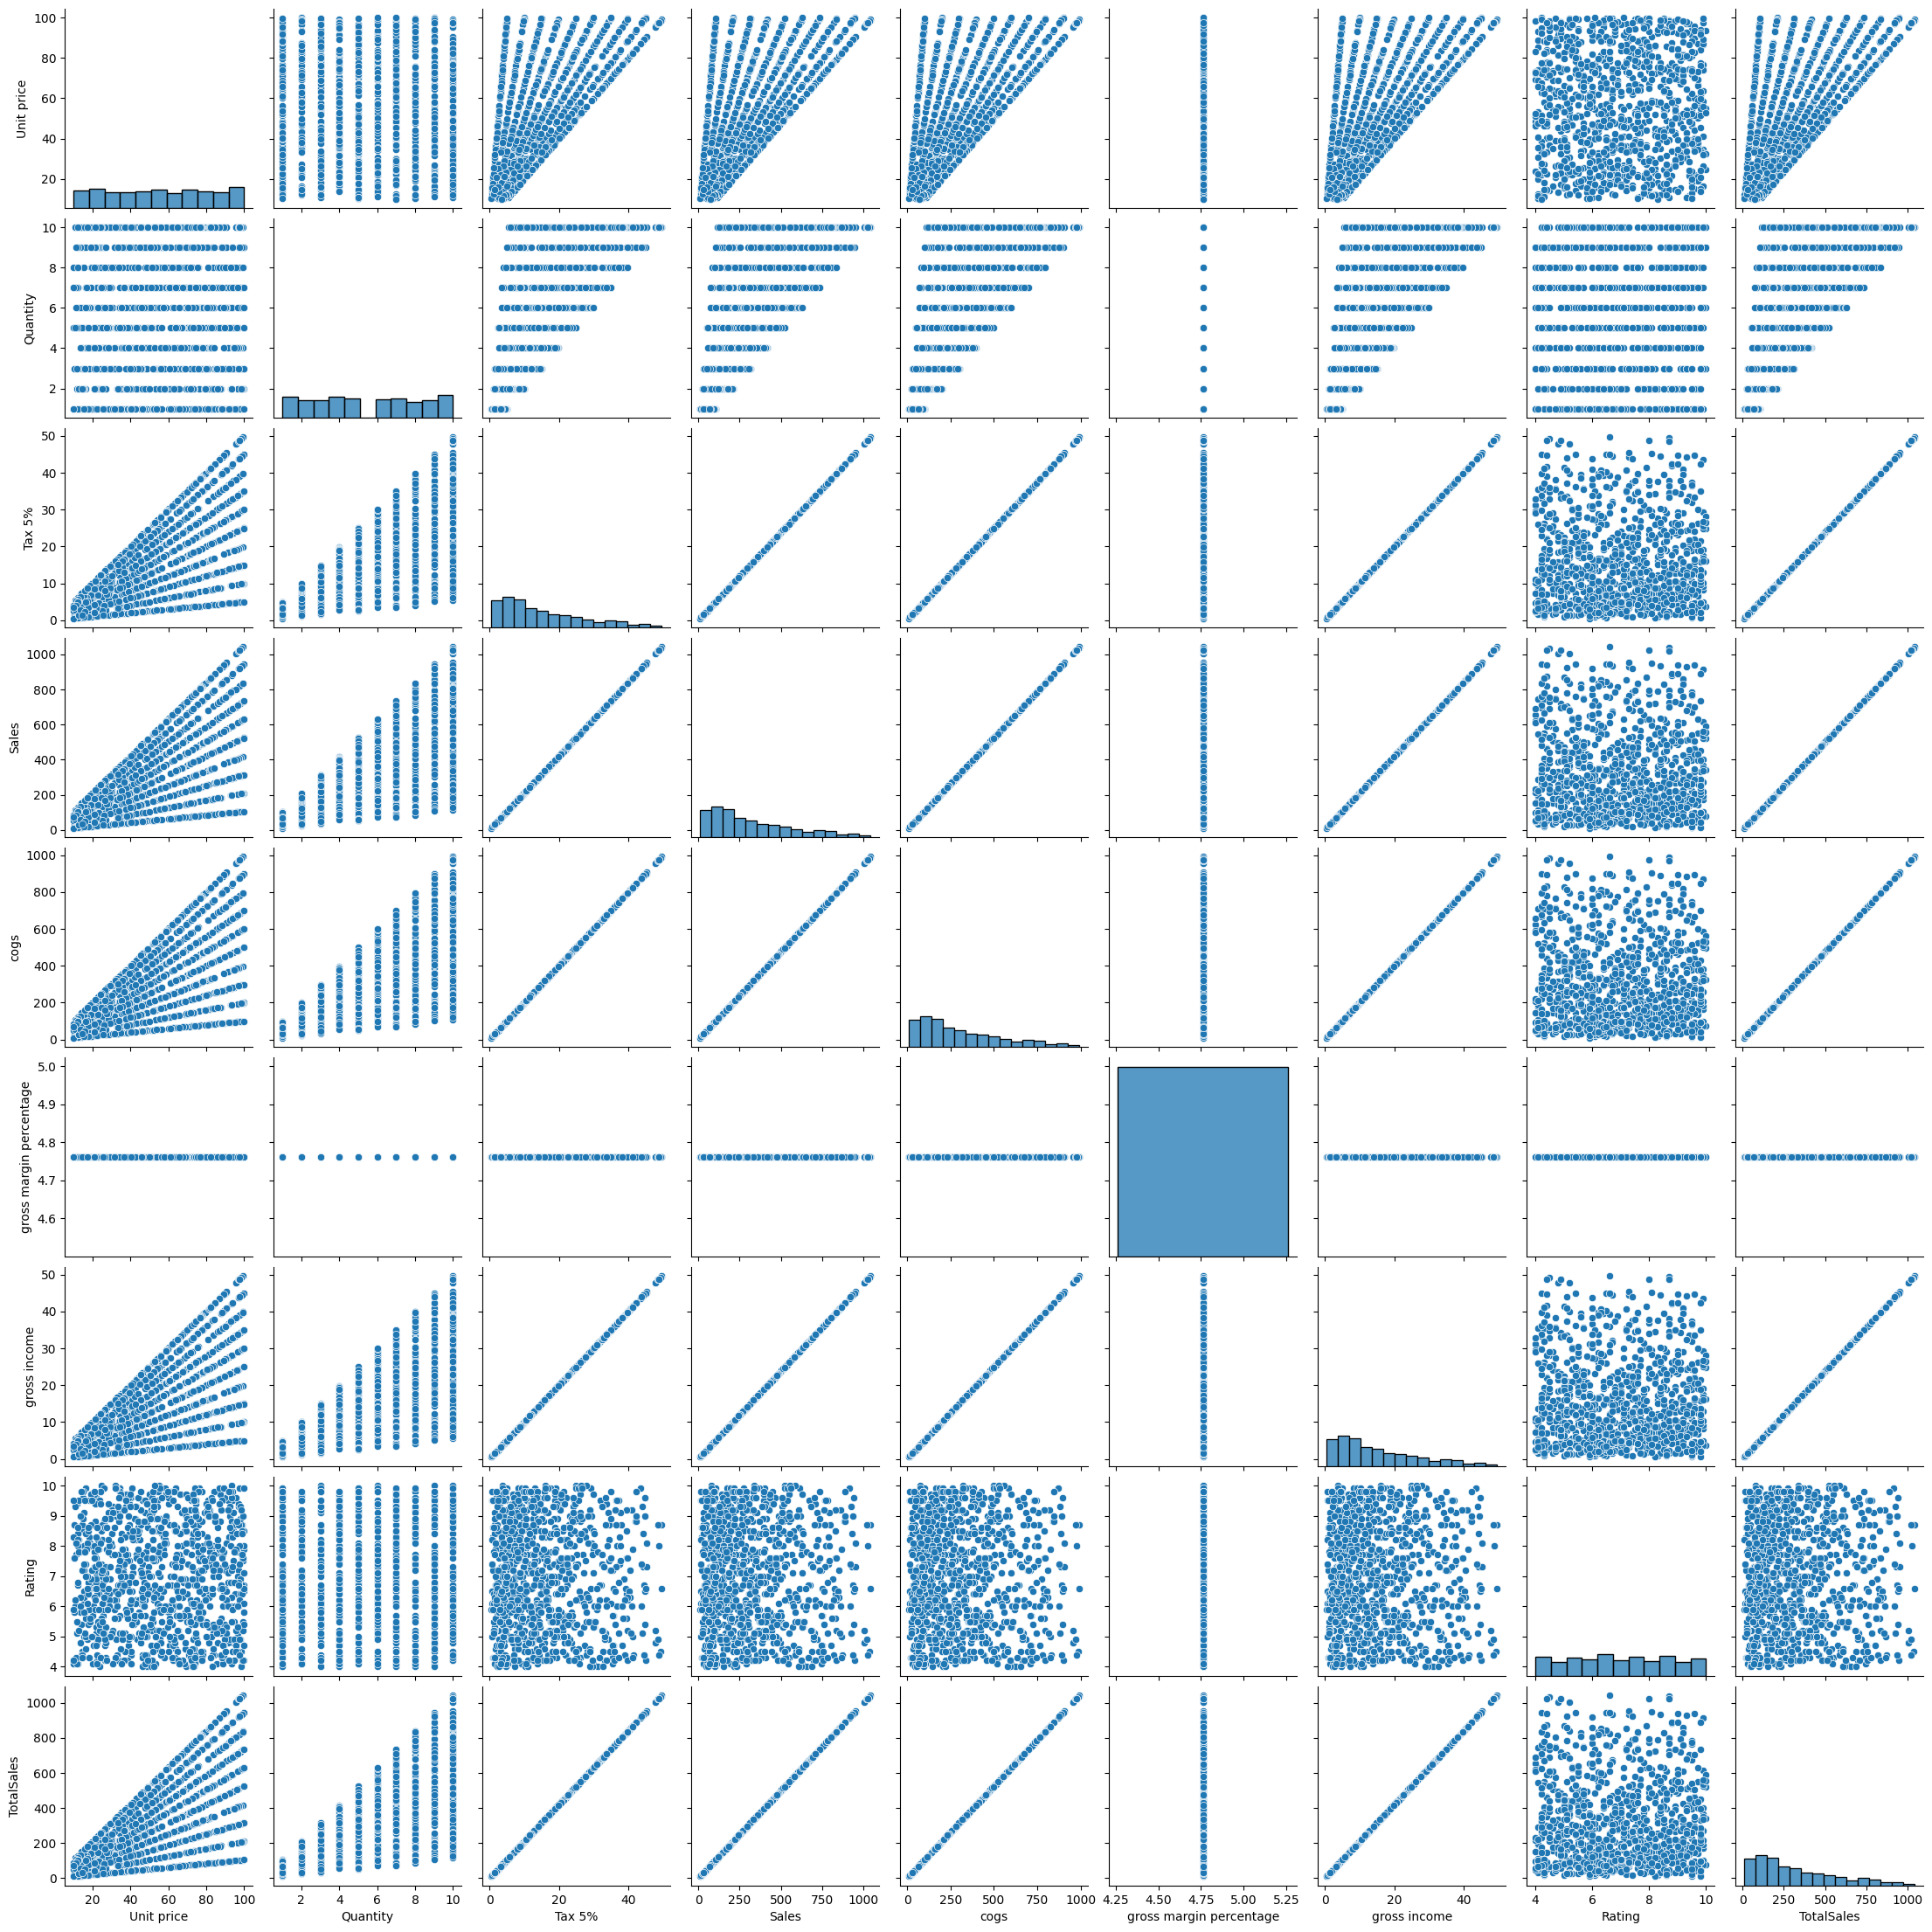

In [28]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
sns.pairplot(numerical_cols)
plt.show()

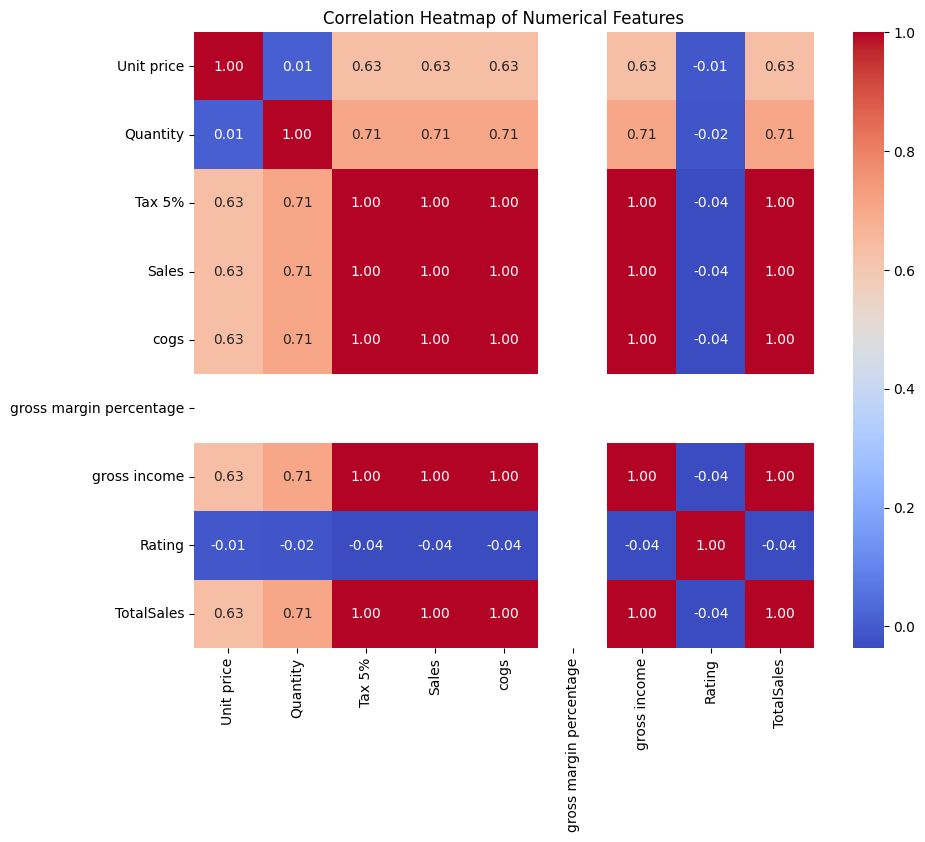

In [32]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## 5. Analytical Insight Questions

1. Which product line generates consistent sales regardless of branch?  

After analyzing the average sales of each product line across different branches, I observed that Food and Beverages shows relatively consistent sales performance in all branches. The variation in its average sales across branches is minimal compared to other categories. This indicates that demand for this product line is stable and not dependent on location, making it a reliable revenue contributor.

2️. Does gender have a significant influence on average sales value?

Based on the comparison of average sales between male and female customers, the difference in spending is very small. Both genders contribute almost equally to the overall revenue. Therefore, gender does not appear to have a significant influence on the average sales value. Purchasing behavior in this dataset seems fairly balanced across genders.

3️. Suggest one insight that could support a business decision.

One important insight from the analysis is that Food and Beverages contribute the highest total sales consistently across branches. This suggests that the business should focus on maintaining sufficient inventory and possibly increasing promotional activities for this product line. Strengthening marketing efforts in high-performing categories could help maximize overall revenue.